### Load Libraries and Dataset

In [189]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [190]:
df = pd.read_csv('C:\Data_Analysis\Laptop Dataset\laptop_price_predictor_FINAL.csv')

### Exploratory Data Analysis (EDA)

In [191]:
df.head()


,Company,Product,Cpu,Ram,Gpu,OpSys,Inches,Price,Cpu_brand,Gpu_brand,HDD,SSD,LogPrice
0,HP,Victus 15-fb0157AX Gaming Laptop,"Hexa Core, 12 Threads",8,4GB AMD Radeon RX 6500M,Windows 11 OS,15.6,49900,"Hexa Core,",4GB,0,512,10.817776
1,HP,15s-fq5007TU Laptop,"Hexa Core (2P + 4E), 8 Threads",8,Intel UHD Graphics,Windows 11 OS,15.6,39900,Hexa Core,Intel,0,512,10.594132
2,Acer,One 14 Z8-415 Laptop,"Dual Core, 4 Threads",8,Intel Iris Xe Graphics,Windows 11 OS,14.0,26990,"Dual Core,",Intel,0,512,10.203222
3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,"12 Cores (4P + 8E), 16 Threads",16,Intel Integrated Iris Xe,Windows 11 OS,14.0,59729,12 Cores,Intel,0,512,10.997573
4,Apple,MacBook Air 2020 MGND3HN Laptop,Octa Core (4P + 4E),8,Apple M1 Integrated Graphics,Mac OS,13.3,69990,Octa Core,Apple,0,256,11.156108


In [192]:
df.tail()

,Company,Product,Cpu,Ram,Gpu,OpSys,Inches,Price,Cpu_brand,Gpu_brand,HDD,SSD,LogPrice
888,Asus,Vivobook 15X 2023 K3504VAB-NJ321WS Laptop,"Hexa Core (2P + 4E), 8 Threads",8,Integrated Intel UHD Graphics,Windows 11 OS,15.6,44990,Hexa Core,Integrated,0,512,10.714196
889,Asus,TUF A15 FA577RM-HQ032WS Laptop,"Octa Core, 16 Threads",16,6GB NVIDIA GeForce RTX 3060,Windows 11 OS,15.6,110000,"Octa Core,",6GB,0,1000,11.608236
890,Asus,ROG Zephyrus G14 2023 GA402XV-N2034WS Gaming L...,"Octa Core, 16 Threads",32,8GB NVIDIA GeForce RTX 4060,Windows 11 OS,14.0,189990,"Octa Core,",8GB,0,1000,12.154727
891,Asus,TUF Gaming F15 2023 FX507VU-LP083WS Gaming Laptop,"14 Cores (6P + 8E), 20 Threads",16,6GB NVIDIA GeForce RTX 4050,Windows 11 OS,15.6,129990,14 Cores,6GB,0,512,11.775213
892,Asus,TUF Gaming A15 2023 FA577XU-LP041WS Gaming Laptop,"Octa Core, 16 Threads",16,6GB NVIDIA GeForce RTX 4050,Windows 11 OS,15.6,131990,"Octa Core,",6GB,0,1000,11.790481


In [193]:
df.shape

(893, 13)

In [194]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Company    893 non-null    object 
 1   Product    893 non-null    object 
 2   Cpu        893 non-null    object 
 3   Ram        893 non-null    int64  
 4   Gpu        893 non-null    object 
 5   OpSys      893 non-null    object 
 6   Inches     893 non-null    float64
 7   Price      893 non-null    int64  
 8   Cpu_brand  893 non-null    object 
 9   Gpu_brand  893 non-null    object 
 10  HDD        893 non-null    int64  
 11  SSD        893 non-null    int64  
 12  LogPrice   893 non-null    float64
dtypes: float64(2), int64(4), object(7)
memory usage: 90.8+ KB


In [195]:
df.describe()

,Ram,Inches,Price,HDD,SSD,LogPrice
count,893.000000,893.000000,893.000000,893.0,893.000000,893.000000
mean,13.251960,15.173751,79907.409854,0.0,594.293393,11.090972
std,6.476961,0.939095,60880.043823,0.0,275.529802,0.601362
min,2.000000,11.600000,9999.000000,0.0,0.000000,9.210240
25%,8.000000,14.000000,44500.000000,0.0,512.000000,10.703244
50%,16.000000,15.600000,61990.000000,0.0,512.000000,11.034728
75%,16.000000,15.600000,90990.000000,0.0,512.000000,11.418505
max,64.000000,18.000000,450039.000000,0.0,2000.000000,13.017090


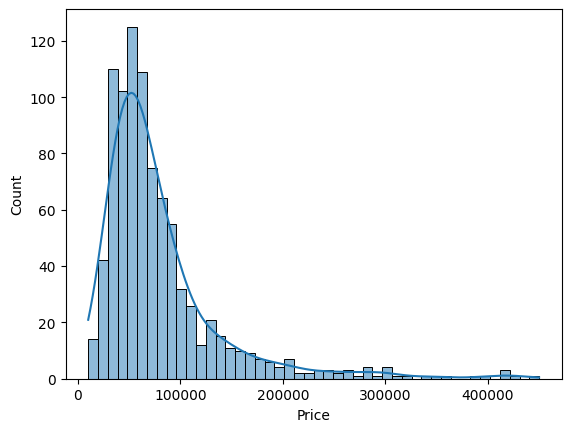

In [196]:
sns.histplot(df["Price"], kde = True)
plt.show() # This shows the skew in the "Price" distribution, which is why I will use a log transformation to reduce the skewness for modeling later

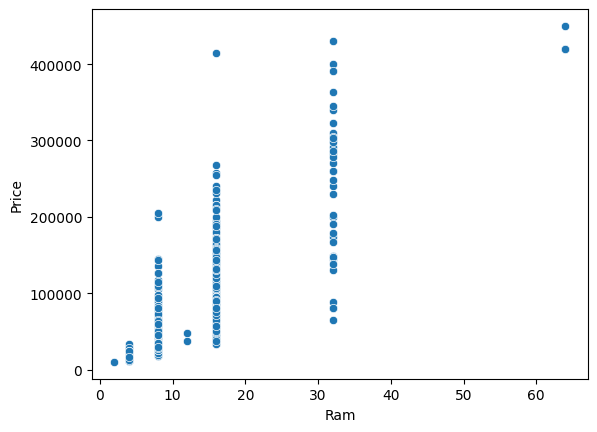

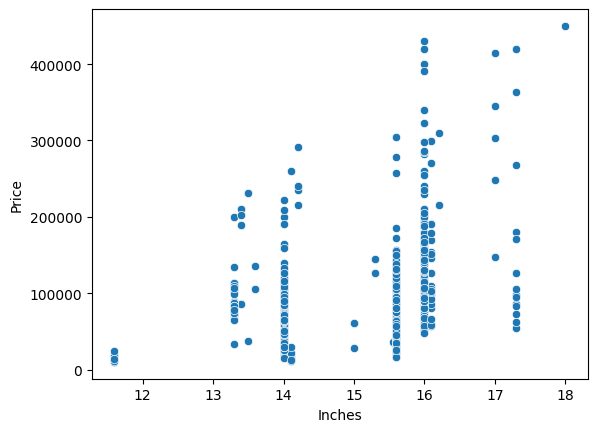

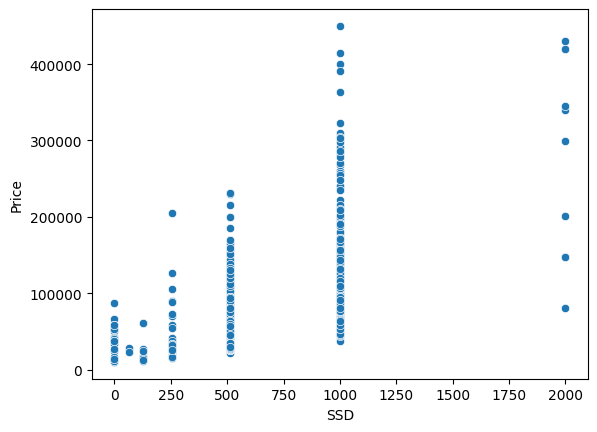

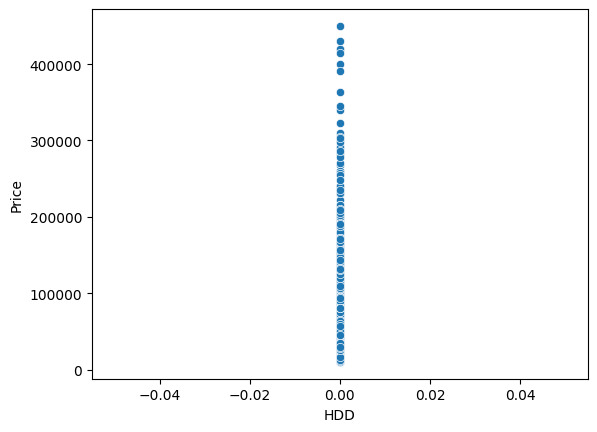

In [197]:
sns.scatterplot(x="Ram", y="Price", data=df)
plt.show()
sns.scatterplot(x="Inches", y="Price", data=df)
plt.show()
sns.scatterplot(x="SSD", y="Price", data=df)
plt.show()
sns.scatterplot(x="HDD", y="Price", data=df)
plt.show()

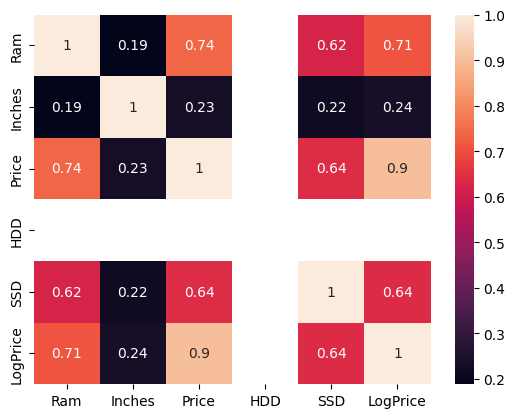

In [198]:
sns.heatmap(df.corr(numeric_only=True), annot=True) # numeric_only=True is used to ignore non-numeric columns and annot=True is to display the vaues in the heatmap
plt.show()

### Data Cleaning

In [199]:
df = df.drop(columns=["Product", "Cpu", "Gpu"])

In [200]:
df.isna().sum()

Company      0
Ram          0
OpSys        0
Inches       0
Price        0
Cpu_brand    0
Gpu_brand    0
HDD          0
SSD          0
LogPrice     0
dtype: int64

In [201]:
df = df.drop_duplicates()

### Feature Engineering

In [202]:
df["LogPrice"] = np.log(df["Price"]) # This reduces the skewness of the price distribution to be more suitable for modeling

In [203]:
def simplify_os(x):
    if "Windows" in x:
        return "Windows"
    elif "Mac" in x:
        return "Mac"
    else:
        return "Other"

df["OpSys"] = df["OpSys"].apply(simplify_os) # This simplifies the operating system categories to make it easier for modeling

In [204]:
df = pd.get_dummies(df, columns=["Company", "Cpu_brand", "Gpu_brand", "OpSys"], drop_first=True) # this is used to convert categorical variables into dummy variables and drop_first=True is used to avoid multicollinearity

### Modeling

In [205]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [206]:
X = df.drop(columns=["Price", "LogPrice"])
y = df["LogPrice"] # Use the "LogPrice" for modeling instead of "Price" to reduce skewness and improve model performance

In [207]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

In [208]:
# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [209]:
# Make prediction on the test set
y_pred = model.predict(X_test)

In [210]:
# Convert the log-transformed prediction back to the original price for the accurate evaluation
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred)

In [211]:
# Evaluate the model performance
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print("-- Model Performance --")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared Score: {r2:.4f}")

-- Model Performance --
Mean Absolute Error: 14018.31
R-squared Score: 0.7048


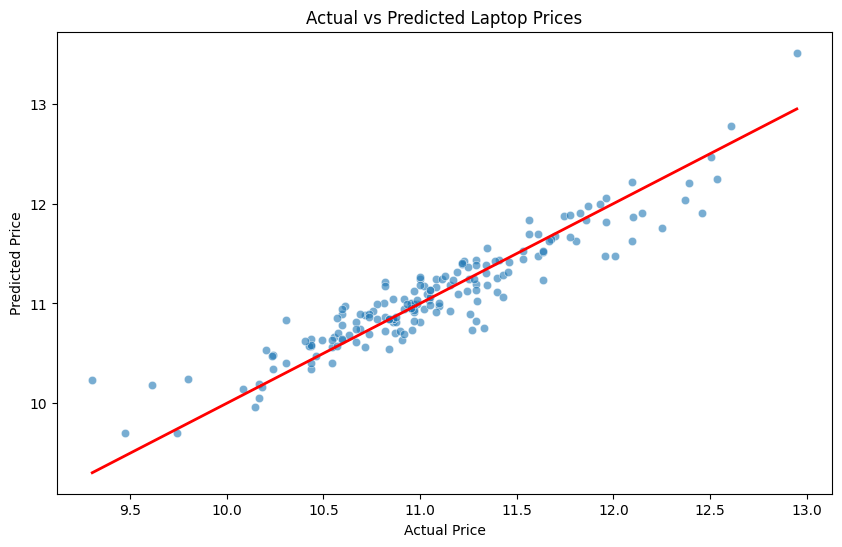

In [212]:
# Visualize the predicted vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Laptop Prices')
plt.show()